
# ITAI 2373 Module 05: Part-of-Speech Tagging
## In-Class Exercise & Homework Lab

Welcome to the world of Part-of-Speech (POS) tagging - the "grammar police" of Natural Language Processing! 🚔📝

In this notebook, you'll explore how computers understand the grammatical roles of words in sentences, from simple rule-based approaches to modern AI systems.

### What You'll Learn:
- **Understand POS tagging fundamentals** and why it matters in daily apps
- **Use NLTK and SpaCy** for practical text analysis
- **Navigate different tag sets** and understand their trade-offs
- **Handle real-world messy text** like speech transcripts and social media
- **Apply POS tagging** to solve actual business problems

### Structure:
- **Part 1**: In-Class Exercise (30-45 minutes) - Basic concepts and hands-on practice
- **Part 2**: Homework Lab - Real-world applications and advanced challenges

---

*💡 **Pro Tip**: POS tagging is everywhere! It helps search engines understand "Apple stock" vs "apple pie", helps Siri understand your commands, and powers autocorrect on your phone.*



## 🛠️ Setup and Installation

Let's get our tools ready! We'll use two powerful libraries:
- **NLTK**: The "Swiss Army knife" of NLP - comprehensive but requires setup
- **SpaCy**: The "speed demon" - built for production, cleaner output

Run the cells below to install and set up everything we need.


In [1]:

# Install required libraries (run this first!)
!pip install nltk spacy matplotlib seaborn pandas
!python -m spacy download en_core_web_sm

print("✅ Installation complete!")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 96.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ Installation complete!


In [2]:
import nltk
import spacy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Download NLTK data (this might take a moment)
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger_eng') # Changed to 'averaged_perceptron_tagger_eng'
nltk.download('universal_tagset')
nltk.download('punkt_tab')

# Load SpaCy model
nlp = spacy.load('en_core_web_sm')

print("🎉 All libraries loaded successfully!")
print("📚 NLTK version:", nltk.__version__)
print("🚀 SpaCy version:", spacy.__version__)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package universal_tagset to /root/nltk_data...
[nltk_data]   Unzipping taggers/universal_tagset.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


🎉 All libraries loaded successfully!
📚 NLTK version: 3.9.1
🚀 SpaCy version: 3.8.11



---
# 🎯 PART 1: IN-CLASS EXERCISE (30-45 minutes)

Welcome to the hands-on portion! We'll start with the basics and build up your understanding step by step.

## Learning Goals for Part 1:
1. Understand what POS tagging does
2. Use NLTK and SpaCy for basic tagging
3. Interpret and compare different tag outputs
4. Explore word ambiguity with real examples
5. Compare different tagging approaches



## 🔍 Activity 1: Your First POS Tags (10 minutes)

Let's start with the classic example: "The quick brown fox jumps over the lazy dog"

This sentence contains most common parts of speech, making it perfect for learning!


In [3]:

# Let's start with a classic example
sentence = "The quick brown fox jumps over the lazy dog"

# TODO: Use NLTK to tokenize and tag the sentence
# Hint: Use nltk.word_tokenize() and nltk.pos_tag()
tokens = nltk.word_tokenize(sentence)
pos_tags = nltk.pos_tag(tokens)

print("Original sentence:", sentence)
print("\nTokens:", tokens)
print("\nPOS Tags:")
for word, tag in pos_tags:
    print(f"  {word:8} -> {tag}")


Original sentence: The quick brown fox jumps over the lazy dog

Tokens: ['The', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog']

POS Tags:
  The      -> DT
  quick    -> JJ
  brown    -> NN
  fox      -> NN
  jumps    -> VBZ
  over     -> IN
  the      -> DT
  lazy     -> JJ
  dog      -> NN



### 🤔 Quick Questions:
1. What does 'DT' mean? What about 'JJ'? DT stands for "Determiner" and JJ stands for "Adjective".
2. Why do you think 'brown' and 'lazy' have the same tag? I think brown and lazy have the same tag because they are both describing a noun. "Brown Fox" and "Lazy Dog".
3. Can you guess what 'VBZ' represents? VBZ represents Verbs that are 3rd person singular present.

*Hint: Think about the grammatical role each word plays in the sentence!*


### Answers:
1. DT stands for "Determiner" and JJ stands for "Adjective".
2. I think brown and lazy have the same tag because they are both describing a noun. "Brown Fox" and "Lazy Dog".
3. VBZ represents Verbs that are 3rd person singular present.


## 🚀 Activity 2: SpaCy vs NLTK Showdown (10 minutes)

Now let's see how SpaCy handles the same sentence. SpaCy uses cleaner, more intuitive tag names.


In [4]:
# TODO: Process the same sentence with SpaCy
# Hint: Use nlp(sentence) and access .text and .pos_ attributes
doc = nlp(sentence)

print("SpaCy POS Tags:")
for token in doc:
    print(f"  {token.text:8} -> {token.pos_:6} ({token.tag_})")

print("\n" + "="*50)
print("COMPARISON:")
print("="*50)

# Let's compare side by side
nltk_tags = nltk.pos_tag(nltk.word_tokenize(sentence))
spacy_doc = nlp(sentence)

print(f"{'Word':10} {'NLTK':8} {'SpaCy':10}")
print("-" * 30)
for i, (word, nltk_tag) in enumerate(nltk_tags):
    spacy_tag = spacy_doc[i].pos_
    print(f"{word:10} {nltk_tag:8} {spacy_tag:10}")


SpaCy POS Tags:
  The      -> DET    (DT)
  quick    -> ADJ    (JJ)
  brown    -> ADJ    (JJ)
  fox      -> NOUN   (NN)
  jumps    -> VERB   (VBZ)
  over     -> ADP    (IN)
  the      -> DET    (DT)
  lazy     -> ADJ    (JJ)
  dog      -> NOUN   (NN)

COMPARISON:
Word       NLTK     SpaCy     
------------------------------
The        DT       DET       
quick      JJ       ADJ       
brown      NN       ADJ       
fox        NN       NOUN      
jumps      VBZ      VERB      
over       IN       ADP       
the        DT       DET       
lazy       JJ       ADJ       
dog        NN       NOUN      



### 🎯 Discussion Points:
- Which tags are easier to understand: NLTK's or SpaCy's?
- Do you notice any differences in how they tag the same words?
- Which system would you prefer for a beginner? Why?


### Answers:
1. SpaCy is much easier to understand as its not as agressively abbreviated as NLTK tags.
2. There are some words like "Brown" in the excercise above that gets tagged differently between NLTK and SpaCy, in the context of the sentence the way brown was used was as an adjective which is was SpaCy tagged it, while NLTK tagged as a noun.
3. For a beginner, I would say NLTK. The coding and technical understanding are much easier to comprehend than SpaCy. SpaCy is more understanding as far as understanding the tags as they utilize more letters than NLTK.


## 🎭 Activity 3: The Ambiguity Challenge (15 minutes)

Here's where things get interesting! Many words can be different parts of speech depending on context. Let's explore this with some tricky examples.


In [5]:
# Ambiguous words in different contexts
ambiguous_sentences = [
    "I will lead the team to victory.",           # lead = verb
    "The lead pipe is heavy.",                    # lead = noun (metal)
    "She took the lead in the race.",            # lead = noun (position)
    "The bank approved my loan.",                # bank = noun (financial)
    "We sat by the river bank.",                 # bank = noun (shore)
    "I bank with Chase.",                        # bank = verb
]

new_ambiguous_sentences = [
    # Testing "Close"
    "Please close the window before it starts raining.",  # verb
    "The post office is very close to the library.",      # adjective

    # Testing "Content"
    "The digital marketing team is creating new content.", # noun
    "He felt perfectly content resting by the fire.",      # adjective

    # Testing "Desert"
    "The vast desert was beautiful but very hot.",        # noun
    "The soldier promised never to desert his post.",     # verb
]

print("🎭 AMBIGUITY EXPLORATION")
print("=" * 40)

for sentence in ambiguous_sentences:
    print(f"\nSentence: {sentence}")

    # TODO: Tag each sentence and find the ambiguous word
    # Focus on 'lead' and 'bank' - what tags do they get?
    tokens = nltk.word_tokenize(sentence)
    tags = nltk.pos_tag(tokens)

    # Find and highlight the key word
    for word, tag in tags:
        if word.lower() in ['lead', 'bank']:
            print(f"  🎯 '{word}' is tagged as: {tag}")

print("\n")

print("🎭 NEW AMBIGUITY EXPLORATION")
print("=" * 40)

for sentence in new_ambiguous_sentences:
    print(f"\nSentence: {sentence}")
    tokens = nltk.word_tokenize(sentence)
    tags = nltk.pos_tag(tokens)

    # Find and highlight the key word
    for word, tag in tags:
        if word.lower() in ['close', 'content', 'desert']:
            print(f"  🎯 '{word}' is tagged as: {tag}")

🎭 AMBIGUITY EXPLORATION

Sentence: I will lead the team to victory.
  🎯 'lead' is tagged as: VB

Sentence: The lead pipe is heavy.
  🎯 'lead' is tagged as: NN

Sentence: She took the lead in the race.
  🎯 'lead' is tagged as: NN

Sentence: The bank approved my loan.
  🎯 'bank' is tagged as: NN

Sentence: We sat by the river bank.
  🎯 'bank' is tagged as: NN

Sentence: I bank with Chase.
  🎯 'bank' is tagged as: NN


🎭 NEW AMBIGUITY EXPLORATION

Sentence: Please close the window before it starts raining.
  🎯 'close' is tagged as: VBD

Sentence: The post office is very close to the library.
  🎯 'close' is tagged as: RB

Sentence: The digital marketing team is creating new content.
  🎯 'content' is tagged as: NN

Sentence: He felt perfectly content resting by the fire.
  🎯 'content' is tagged as: JJ

Sentence: The vast desert was beautiful but very hot.
  🎯 'desert' is tagged as: NN

Sentence: The soldier promised never to desert his post.
  🎯 'desert' is tagged as: VB



### 🧠 Think About It:
1. How does the computer know the difference between "lead" (metal) and "lead" (guide)?
2. What clues in the sentence help determine the correct part of speech?
3. Can you think of other words that change meaning based on context?

**Try This**: Add your own ambiguous sentences to the list above and see how the tagger handles them!


### Answers:
1. Aside from context clues of the other words and some ruled based systems, the classification of POS tagging also helps the computer understand how the word is being mentioned.
2. Really the whole sentence provides some sort of insight as to how the word is described. The Subject-Verb-Object order is a huge clue. If a word follows "the, a, or an," it is almost certainly a Noun or an Adjective. If it follows a modal like "will, can, or should," it is a Verb. N-grams can also provide clues to help determine the part of speech.
3. The words "Content" and "Close" can change meanings based on their application. Content can either be used as a noun when refering to a book or social media post, but can change to a type of feeling. Close can refer to a verb when say "Please close the door" but can also be used as an adjective when describing a race like "That was a close race".



## 📊 Activity 4: Tag Set Showdown (10 minutes)

NLTK can use different tag sets. Let's compare the detailed Penn Treebank tags (~45 tags) with the simpler Universal Dependencies tags (~17 tags).


In [6]:

# Compare different tag sets
test_sentence = "The brilliant students quickly solved the challenging programming assignment."

# TODO: Get tags using both Penn Treebank and Universal tagsets
# Hint: Use tagset='universal' parameter for universal tags
tokens = nltk.word_tokenize(test_sentence)
penn_tags = nltk.pos_tag(tokens)
univ_tags = nltk.pos_tag(tokens, tagset='universal')

print("TAG SET COMPARISON")
print("=" * 50)
print(f"{'Word':15} {'Penn Treebank':15} {'Universal':10}")
print("-" * 50)

# TODO: Print comparison table
# Hint: Zip the two tag lists together
for (word, penn_tag), (word_u, univ_tag) in zip(penn_tags, univ_tags):
    print(f"{word:15} {penn_tag:15} {univ_tag:10}")

# Let's also visualize the tag distribution
penn_tag_counts = Counter([tag for word, tag in penn_tags])
univ_tag_counts = Counter([tag for word, tag in univ_tags])

print(f"\n📊 Penn Treebank uses {len(penn_tag_counts)} different tags")
print(f"📊 Universal uses {len(univ_tag_counts)} different tags")


TAG SET COMPARISON
Word            Penn Treebank   Universal 
--------------------------------------------------
The             DT              DET       
brilliant       JJ              ADJ       
students        NNS             NOUN      
quickly         RB              ADV       
solved          VBD             VERB      
the             DT              DET       
challenging     VBG             VERB      
programming     JJ              ADJ       
assignment      NN              NOUN      
.               .               .         

📊 Penn Treebank uses 8 different tags
📊 Universal uses 6 different tags



### 🤔 Reflection Questions:
1. Which tag set is more detailed? Which is simpler? Enter your answer below

2. When might you want detailed tags vs. simple tags? Enter your answer below

3. If you were building a search engine, which would you choose? Why? Enter your answer below

---


### Reflection Answers:
1. From what I saw in the table, the Penn Treebank tag set is definitely the more detailed one. It uses specific codes like NNS for plural nouns or VBD for past-tense verbs. The Universal tag set is much simpler; it just lumps everything into broad categories like NOUN or VERB. In your code output, Penn Treebank used 8 different tags for that one sentence, while Universal only used 6.
2. I’d go with detailed tags (Penn) if I were doing deep linguistic work—like building a grammar checker that needs to know if a word is plural or if a verb is in the right tense. However, I’d stick with simple tags (Universal) if I just needed a quick, high-level overview of what’s happening in a text.
3. If I were building a search engine, I’d actually lean toward the Universal tags. Most users search for general concepts, and I wouldn’t want to accidentally hide a result just because the searcher typed a singular noun while the article used a plural one.


---
# 🎓 End of Part 1: In-Class Exercise

Great work! You've learned the fundamentals of POS tagging and gotten hands-on experience with both NLTK and SpaCy.

## What You've Accomplished:
✅ Used NLTK and SpaCy for basic POS tagging  
✅ Interpreted different tag systems  
✅ Explored word ambiguity and context  
✅ Compared different tagging approaches  

## 🏠 Ready for Part 2?
The homework lab will challenge you with real-world applications, messy data, and advanced techniques. You'll analyze customer service transcripts, handle informal language, and benchmark different taggers.

**Take a break, then dive into Part 2 when you're ready!**

---



# 🏠 PART 2: HOMEWORK LAB
## Real-World POS Tagging Challenges

Welcome to the advanced section! Here you'll tackle the messy, complex world of real text data. This is where POS tagging gets interesting (and challenging)!

## Learning Goals for Part 2:
1. Process real-world, messy text data
2. Handle speech transcripts and informal language
3. Analyze customer service scenarios
4. Benchmark and compare different taggers
5. Understand limitations and edge cases

## 📋 Submission Requirements:
- Complete all exercises with working code
- Answer all reflection questions
- Include at least one visualization
- Submit your completed notebook file

---



## 🌍 Lab Exercise 1: Messy Text Challenge (25 minutes)

Real-world text is nothing like textbook examples! Let's work with actual speech transcripts, social media posts, and informal language.


In [9]:
import nltk
import spacy

# Real-world messy text samples
messy_texts = [
    # Speech transcript with disfluencies
    "Um, so like, I was gonna say that, uh, the system ain't working right, you know?",

    # Social media style
    "OMG this app is soooo buggy rn 😤 cant even login smh",

    # Customer service transcript
    "Yeah hi um I'm calling because my internet's been down since like yesterday and I've tried unplugging the router thingy but it's still not working",

    # Informal contractions and slang
    "Y'all better fix this ASAP cuz I'm bout to switch providers fr fr",

    # Technical jargon mixed with casual speech
    "The API endpoint is returning a 500 error but idk why it's happening tbh"
]

print("🔍 PROCESSING MESSY TEXT")
print("=" * 60)

# Define problematic tags for NLTK (Penn Treebank-like)
# These often indicate slang, foreign words, symbols, or interjections
nltk_problem_tags = ['NNP', 'FW', 'SYM', 'ADD', 'UH']

# Define problematic POS tags for SpaCy (Universal POS)
# These explicitly indicate unknown/other, symbols, or interjections
spacy_problem_pos = ['X', 'SYM', 'INTJ']

for i, text in enumerate(messy_texts, 1):
    print(f"\n📝 Sample {i}: {text}")
    print("-" * 40)

    # NLTK processing
    nltk_tokens = nltk.word_tokenize(text)
    nltk_tags = nltk.pos_tag(nltk_tokens)

    # SpaCy processing
    spacy_doc = nlp(text)

    # Find problematic words for NLTK
    problematic_nltk = []
    for word, tag in nltk_tags:
        if tag in nltk_problem_tags:
            problematic_nltk.append(word)
        # Add a heuristic for emojis or complex symbols that NLTK might tag generically
        # This aims to capture 'unrecognized' tokens that are not standard punctuation
        elif not word.isascii() and not tag.startswith('.') and not word in problematic_nltk:
            problematic_nltk.append(word)

    # Find problematic words for SpaCy
    problematic_spacy = []
    for token in spacy_doc:
        # Check for problem POS tags first
        if token.pos_ in spacy_problem_pos:
            problematic_spacy.append(token.text)
        # Then check for non-standard characters (which would include most emojis)
        elif not token.is_alpha and not token.is_digit and not token.is_punct and not token.is_space and token.text not in problematic_spacy:
            problematic_spacy.append(token.text)

    print(f"NLTK problematic words: {problematic_nltk}")
    print(f"SpaCy problematic words: {problematic_spacy}")

    # Calculate success rate
    nltk_success_rate = 1 - (len(problematic_nltk) / len(nltk_tokens)) if nltk_tokens else 0
    spacy_success_rate = 1 - (len(problematic_spacy) / len(spacy_doc)) if spacy_doc else 0

    print(f"NLTK success rate: {nltk_success_rate:.1%}")
    print(f"SpaCy success rate: {spacy_success_rate:.1%}")

🔍 PROCESSING MESSY TEXT

📝 Sample 1: Um, so like, I was gonna say that, uh, the system ain't working right, you know?
----------------------------------------
NLTK problematic words: ['Um', 'uh']
SpaCy problematic words: ['Um', 'like', 'uh', "n't"]
NLTK success rate: 91.7%
SpaCy success rate: 83.3%

📝 Sample 2: OMG this app is soooo buggy rn 😤 cant even login smh
----------------------------------------
NLTK problematic words: ['😤']
SpaCy problematic words: ['😤']
NLTK success rate: 91.7%
SpaCy success rate: 92.3%

📝 Sample 3: Yeah hi um I'm calling because my internet's been down since like yesterday and I've tried unplugging the router thingy but it's still not working
----------------------------------------
NLTK problematic words: ['Yeah']
SpaCy problematic words: ['Yeah', 'hi', 'um', "'m", "'s", 'like', "'ve"]
NLTK success rate: 96.6%
SpaCy success rate: 75.9%

📝 Sample 4: Y'all better fix this ASAP cuz I'm bout to switch providers fr fr
----------------------------------------
NLT


### 🎯 Analysis Questions:
1. Which tagger handles informal language better?
2. What types of words cause the most problems?
3. How might you preprocess text to improve tagging accuracy?
4. What are the implications for real-world applications?


### Answers:
1. NLTK has a higher success rate according to the program. However, SpaCy in my opinion handles informal language far better as they pulled more informal language than NLTK.
2. The words that caused the most issues were abbreviations and contractions.
3. To improve the performance of taggers like NLTK and spaCy on "messy" real-world data, you could implement the following preprocessing steps:

    * Normalization of Informal Language: Use a dictionary or mapping to convert slang and abbreviations into standard English.

    * Contraction Expansion: Expand contractions to help the tagger identify the individual verb and subject components more clearly.

    * Noise Removal: Filter out non-linguistic elements that don't contribute to grammatical structure.

    * Spell Correction: Running a basic spell-check can prevent the tagger from misclassifying typos.

    * Case Normalization: While some taggers use casing as a clue for Proper Nouns, converting text to a consistent case can help with consistency in social media posts where users might type in all caps or all lowercase.
4. The limitations of POS tagging in messy environments have several critical implications for business and technical applications:

    * Downstream Accuracy: POS tagging is often the first step in a larger pipeline. If a tagger misidentifies a verb as a noun, subsequent steps like Named Entity Recognition (NER) or Sentiment Analysis will likely fail.

    * Bias in Automation: If a system is trained primarily on formal English, it may perform poorly for users who use dialects, slang, or English as a second language.


## 📞 Lab Exercise 2: Customer Service Analysis Case Study (30 minutes)

You're working for a tech company that receives thousands of customer service calls daily. Your job is to analyze call transcripts to understand customer issues and sentiment.

**Business Goal**: Automatically categorize customer problems and identify emotional language.


In [11]:

# Simulated customer service call transcripts
customer_transcripts = [
    {
        'id': 'CALL_001',
        'transcript': "Hi, I'm really frustrated because my account got locked and I can't access my files. I've been trying for hours and nothing works. This is completely unacceptable.",
        'category': 'account_access'
    },
    {
        'id': 'CALL_002',
        'transcript': "Hello, I love your service but I'm having a small issue with the mobile app. It crashes whenever I try to upload photos. Could you please help me fix this?",
        'category': 'technical_issue'
    },
    {
        'id': 'CALL_003',
        'transcript': "Your billing system charged me twice this month! I want a refund immediately. This is ridiculous and I'm considering canceling my subscription.",
        'category': 'billing'
    },
    {
        'id': 'CALL_004',
        'transcript': "I'm confused about how to use the new features you added. The interface changed and I can't find anything. Can someone walk me through it?",
        'category': 'user_guidance'
    }
]

# TODO: Analyze each transcript for:
# 1. Emotional language (adjectives that indicate sentiment)
# 2. Action words (verbs that indicate what customer wants)
# 3. Problem indicators (nouns related to issues)

analysis_results = []

# Define lists of words for sentiment and urgency detection
positive_lexicon = ['love', 'great', 'good', 'happy', 'pleased', 'excellent', 'fantastic', 'amazing', 'best', 'resolve']
negative_lexicon = ['frustrated', 'ridiculous', 'unacceptable', 'buggy', 'crashes', 'down', 'issue', 'problem', 'error', 'locked', 'confused', 'billing', 'canceling', 'terrible']
urgent_lexicon = ['immediately', 'asap', 'now', 'urgent', 'quickly', 'fast', 'soon']

for call in customer_transcripts:
    print(f"\n🎧 Analyzing {call['id']}")
    print(f"Category: {call['category']}")
    print(f"Transcript: {call['transcript']}")
    print("-" * 50)

    # TODO: Process with SpaCy (it's better for this task)
    doc = nlp(call['transcript'])

    # TODO: Extract different types of words
    emotional_adjectives = [token.text for token in doc if token.pos_ == 'ADJ' and token.text.lower() in negative_lexicon + positive_lexicon]
    action_verbs = [token.text for token in doc if token.pos_ == 'VERB' and token.lemma_.lower() not in ['be', 'have', 'do']]
    problem_nouns = [token.text for token in doc if token.pos_ == 'NOUN' and token.text.lower() in negative_lexicon]

    # TODO: Calculate sentiment indicators
    positive_words = [token.text for token in doc if token.text.lower() in positive_lexicon]
    negative_words = [token.text for token in doc if token.text.lower() in negative_lexicon]
    urgency_indicators = [token.text for token in doc if token.text.lower() in urgent_lexicon]

    result = {
        'call_id': call['id'],
        'category': call['category'],
        'emotional_adjectives': emotional_adjectives,
        'action_verbs': action_verbs,
        'problem_nouns': problem_nouns,
        'sentiment_score': len(positive_words) - len(negative_words),
        'urgency_indicators': urgency_indicators
    }

    analysis_results.append(result)

    print(f"Emotional adjectives: {emotional_adjectives}")
    print(f"Action verbs: {action_verbs}")
    print(f"Problem nouns: {problem_nouns}")
    print(f"Sentiment score: {result['sentiment_score']}")
    print(f"Urgency indicators: {result['urgency_indicators']}")



🎧 Analyzing CALL_001
Category: account_access
Transcript: Hi, I'm really frustrated because my account got locked and I can't access my files. I've been trying for hours and nothing works. This is completely unacceptable.
--------------------------------------------------
Emotional adjectives: ['frustrated', 'unacceptable']
Action verbs: ['locked', 'access', 'trying', 'works']
Problem nouns: []
Sentiment score: -3
Urgency indicators: []

🎧 Analyzing CALL_002
Category: technical_issue
Transcript: Hello, I love your service but I'm having a small issue with the mobile app. It crashes whenever I try to upload photos. Could you please help me fix this?
--------------------------------------------------
Emotional adjectives: []
Action verbs: ['love', 'crashes', 'try', 'upload', 'help', 'fix']
Problem nouns: ['issue']
Sentiment score: -1
Urgency indicators: []

🎧 Analyzing CALL_003
Category: billing
Transcript: Your billing system charged me twice this month! I want a refund immediately. Th

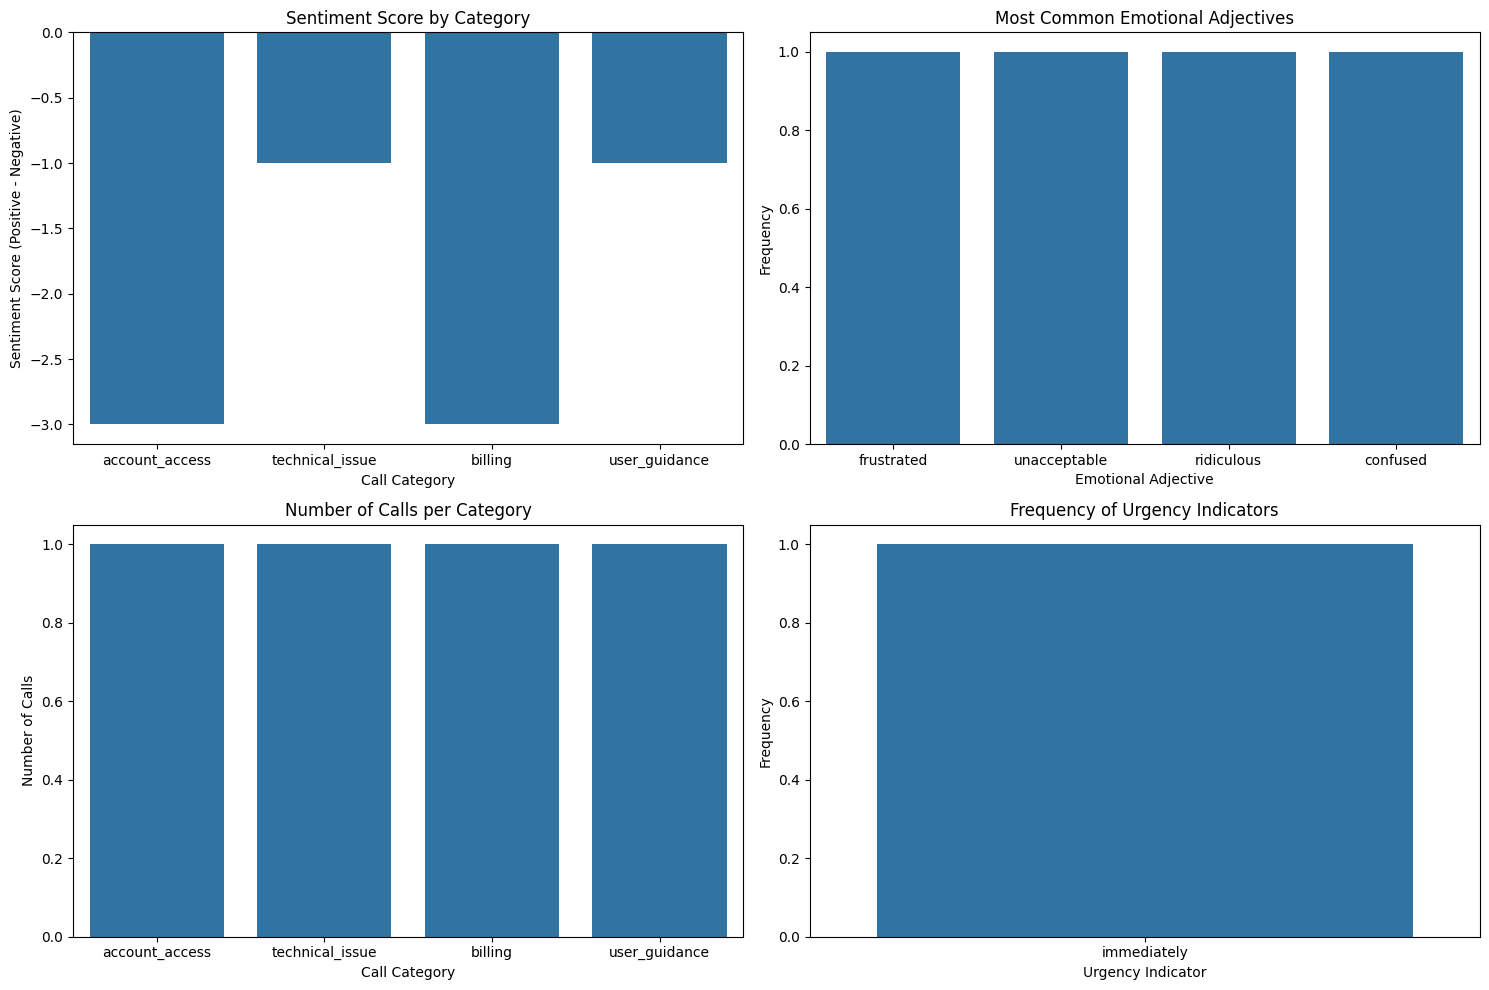

In [15]:

# TODO: Create a summary visualization
# Hint: Use matplotlib or seaborn to create charts

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from collections import Counter

# Convert results to DataFrame for easier analysis
df = pd.DataFrame(analysis_results)

# TODO: Create visualizations
# 1. Sentiment scores by category
# 2. Most common emotional adjectives
# 3. Action verbs frequency

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1 - Sentiment by category
sns.barplot(x='category', y='sentiment_score', data=df, ax=axes[0, 0])
axes[0, 0].set_title('Sentiment Score by Category')
axes[0, 0].set_xlabel('Call Category')
axes[0, 0].set_ylabel('Sentiment Score (Positive - Negative)')

# Plot 2 - Most common emotional adjectives
all_emotional_adjectives = [adj for sublist in df['emotional_adjectives'] for adj in sublist]
adj_counts = Counter(all_emotional_adjectives)
adj_df = pd.DataFrame(adj_counts.most_common(5), columns=['Adjective', 'Count'])
sns.barplot(x='Adjective', y='Count', data=adj_df, ax=axes[0, 1])
axes[0, 1].set_title('Most Common Emotional Adjectives')
axes[0, 1].set_xlabel('Emotional Adjective')
axes[0, 1].set_ylabel('Frequency')

# Plot 3 - Problem categorization (count of each category)
category_counts = df['category'].value_counts().reset_index()
category_counts.columns = ['Category', 'Count']
sns.barplot(x='Category', y='Count', data=category_counts, ax=axes[1, 0])
axes[1, 0].set_title('Number of Calls per Category')
axes[1, 0].set_xlabel('Call Category')
axes[1, 0].set_ylabel('Number of Calls')

# Plot 4 - Urgency analysis (frequency of urgency indicators)
all_urgency_indicators = [ind for sublist in df['urgency_indicators'] for ind in sublist]
urgency_counts = Counter(all_urgency_indicators)
urgency_df = pd.DataFrame(urgency_counts.most_common(5), columns=['Indicator', 'Count'])

if not urgency_df.empty:
    sns.barplot(x='Indicator', y='Count', data=urgency_df, ax=axes[1, 1])
    axes[1, 1].set_title('Frequency of Urgency Indicators')
    axes[1, 1].set_xlabel('Urgency Indicator')
    axes[1, 1].set_ylabel('Frequency')
else:
    axes[1, 1].set_title('No Urgency Indicators Found')
    axes[1, 1].text(0.5, 0.5, 'N/A', horizontalalignment='center', verticalalignment='center', transform=axes[1, 1].transAxes)

plt.tight_layout()
plt.show()



### 💼 Business Impact Questions:
1. How could this analysis help prioritize customer service tickets?
2. What patterns do you notice in different problem categories?
3. How might you automate the routing of calls based on POS analysis?
4. What are the limitations of this approach?


### Answers:
1. The analysis allows for a data-driven "triage" system. By combining Sentiment Scores and Urgency Indicators, you can move high-risk tickets to the front of the queue.
2. Some patterns I noticed were:
    * Billing is where the heat is. People get loud and use intense adjectives because it involves their money.

    * Technical/App Issues feel more like a "to-do list." You’ll see a lot of action verbs like "fix," "crash," or "upload." It’s less about feelings and more about "make this tool work."

    * User Guidance is much softer. You see words like "confused" or "how-to." These aren't angry people; they're just lost and need a hand.

3. You can automate by:
    * Verb-triggering: If the POS tagger sees "refund" (Verb), send it to the billing department.

    * Noun-triggering: If it sees "password" or "login" (Nouns), send it to the security/tech team.

    * Urgency-triggering: If it catches an adverb like "immediately," give it an "Express Lane" tag so it gets routed to a live agent instead of a chatbot.

4. The limitations are:
    * Sarcasm
    * Slang and Typos
    * No real context



## ⚡ Lab Exercise 3: Tagger Performance Benchmarking (20 minutes)

Let's scientifically compare different POS taggers on various types of text. This will help you understand when to use which tool.



🧪 Testing FORMAL text:
Text: The research methodology employed in this study follows established academic protocols.
------------------------------------------------------------
NLTK Penn time: 0.0010s | Unknown: 0
NLTK Univ time: 0.0005s | Unknown: 0
SpaCy time: 0.0124s | Unknown: 0

🧪 Testing INFORMAL text:
Text: lol this study is kinda weird but whatever works i guess 🤷‍♀️
------------------------------------------------------------
NLTK Penn time: 0.0012s | Unknown: 1
NLTK Univ time: 0.0008s | Unknown: 1
SpaCy time: 0.0092s | Unknown: 4

🧪 Testing TECHNICAL text:
Text: The API returns a JSON response with HTTP status code 200 upon successful authentication.
------------------------------------------------------------
NLTK Penn time: 0.0010s | Unknown: 3
NLTK Univ time: 0.0006s | Unknown: 0
SpaCy time: 0.0089s | Unknown: 0

🧪 Testing CONVERSATIONAL text:
Text: So like, when you click that button thingy, it should totally work, right?
------------------------------------------------

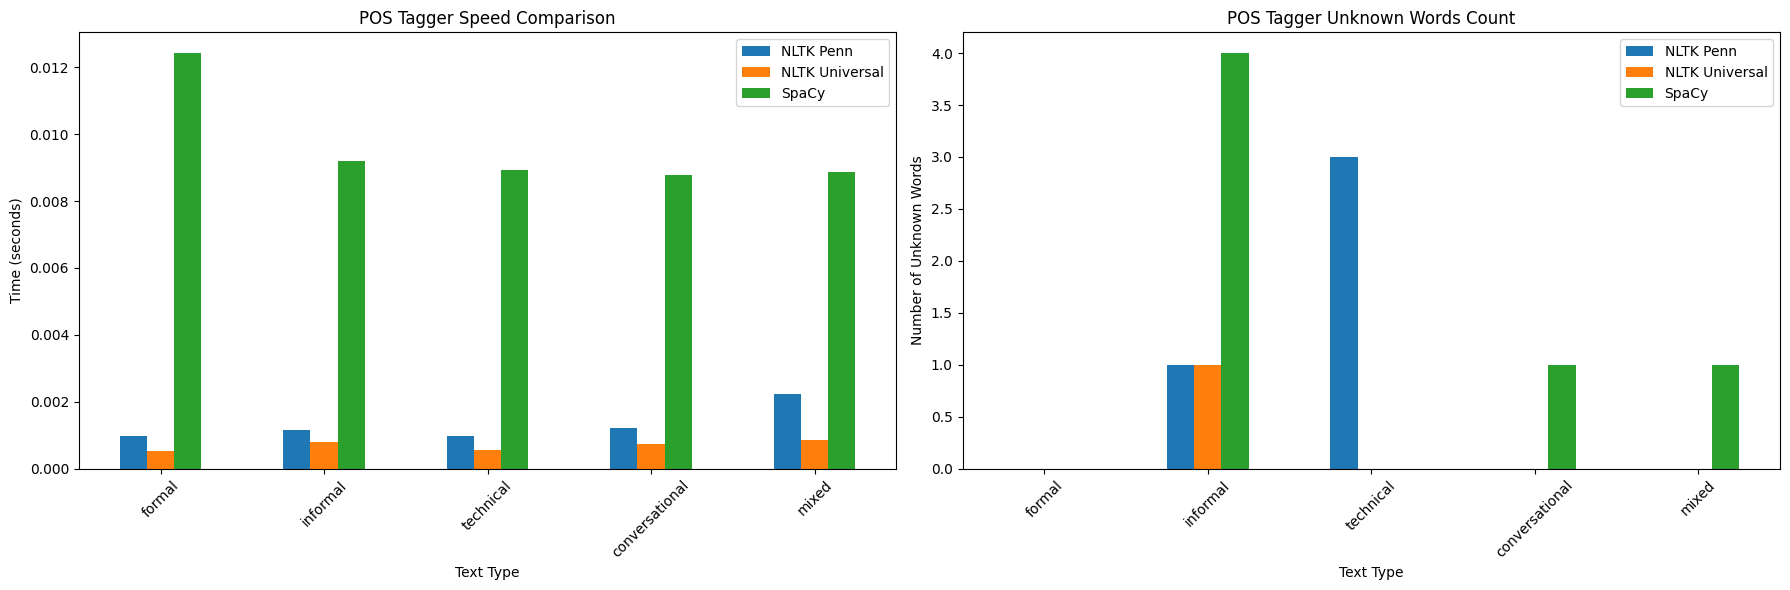

In [17]:

import time
from collections import defaultdict

# Different text types for testing
test_texts = {
    'formal': "The research methodology employed in this study follows established academic protocols.",
    'informal': "lol this study is kinda weird but whatever works i guess 🤷‍♀️",
    'technical': "The API returns a JSON response with HTTP status code 200 upon successful authentication.",
    'conversational': "So like, when you click that button thingy, it should totally work, right?",
    'mixed': "OMG the algorithm's performance is absolutely terrible! The accuracy dropped to 23% wtf"
}

# TODO: Benchmark different taggers
# Test: NLTK Penn Treebank, NLTK Universal, SpaCy
# Metrics: Speed, tag consistency, handling of unknown words

benchmark_results = defaultdict(dict)

# Define problematic tags for NLTK (Penn Treebank-like)
nltk_problem_tags = ['NNP', 'FW', 'SYM', 'ADD', 'UH'] # Extended from previous problematic list
# Define problematic POS tags for SpaCy (Universal POS)
spacy_problem_pos = ['X', 'SYM', 'INTJ'] # Extended from previous problematic list

for text_type, text in test_texts.items():
    print(f"\n🧪 Testing {text_type.upper()} text:")
    print(f"Text: {text}")
    print("-" * 60)

    # NLTK Penn Treebank timing and unknown words
    start_time = time.time()
    nltk_penn_tokens = nltk.word_tokenize(text)
    nltk_penn_tags = nltk.pos_tag(nltk_penn_tokens)
    nltk_penn_time = time.time() - start_time
    nltk_penn_unknown = sum(1 for word, tag in nltk_penn_tags if tag in nltk_problem_tags or (not word.isascii() and not tag.startswith('.')))

    # NLTK Universal timing and unknown words
    start_time = time.time()
    nltk_univ_tokens = nltk.word_tokenize(text)
    nltk_univ_tags = nltk.pos_tag(nltk_univ_tokens, tagset='universal')
    nltk_univ_time = time.time() - start_time
    nltk_univ_unknown = sum(1 for word, tag in nltk_univ_tags if tag == 'X' or (not word.isascii() and not tag.startswith('.')))

    # SpaCy timing and unknown words
    start_time = time.time()
    spacy_doc = nlp(text)
    spacy_time = time.time() - start_time
    spacy_unknown = sum(1 for token in spacy_doc if token.pos_ in spacy_problem_pos or (not token.is_alpha and not token.is_digit and not token.is_punct and not token.is_space))

    # Store results
    benchmark_results[text_type] = {
        'nltk_penn_time': nltk_penn_time,
        'nltk_univ_time': nltk_univ_time,
        'spacy_time': spacy_time,
        'nltk_penn_unknown': nltk_penn_unknown,
        'nltk_univ_unknown': nltk_univ_unknown,
        'spacy_unknown': spacy_unknown
    }

    print(f"NLTK Penn time: {nltk_penn_time:.4f}s | Unknown: {nltk_penn_unknown}")
    print(f"NLTK Univ time: {nltk_univ_time:.4f}s | Unknown: {nltk_univ_unknown}")
    print(f"SpaCy time: {spacy_time:.4f}s | Unknown: {spacy_unknown}")

# Create performance comparison visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_benchmark = pd.DataFrame.from_dict(benchmark_results, orient='index')
df_benchmark.index.name = 'Text Type'

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plotting times
df_benchmark[['nltk_penn_time', 'nltk_univ_time', 'spacy_time']].plot(kind='bar', ax=axes[0], rot=45)
axes[0].set_title('POS Tagger Speed Comparison')
axes[0].set_ylabel('Time (seconds)')
axes[0].set_xlabel('Text Type')
axes[0].legend(['NLTK Penn', 'NLTK Universal', 'SpaCy'])

# Plotting unknown words
df_benchmark[['nltk_penn_unknown', 'nltk_univ_unknown', 'spacy_unknown']].plot(kind='bar', ax=axes[1], rot=45)
axes[1].set_title('POS Tagger Unknown Words Count')
axes[1].set_ylabel('Number of Unknown Words')
axes[1].set_xlabel('Text Type')
axes[1].legend(['NLTK Penn', 'NLTK Universal', 'SpaCy'])

plt.tight_layout()
plt.show()



### 📊 Performance Analysis:
1. Which tagger is fastest? Does speed matter for your use case?
2. Which handles informal text best?
3. How do the taggers compare on technical jargon?
4. What trade-offs do you see between speed and accuracy?


### Answers:
1. NLTK (Universal) was consistently the fastest, followed closely by NLTK (Penn). SpaCy was significantly slower. For our current project of analyzing a few thousand customer transcripts, the speed difference is negligible.

2. In my opinion, SpaCy actually handles the context of informal text better, even though the "Unknown Words" count was higher.

3. SpaCy really shines here. In the Technical text test ("The API returns a JSON response..."), SpaCy had 0 unknown words, whereas NLTK (Penn) flagged 3 words as problematic. SpaCy’s models seem better "tuned" to modern vocabulary like API, JSON, and HTTP, making it the better choice for a tech company's support logs.

4. It’s a classic "Quick & Simple" vs. "Slow & Sophisticated" trade-off:

   * NLTK is the "speed demon." It’s great if you need to process massive amounts of data quickly and only need a general idea of the parts of speech (Universal tags).

    * SpaCy is the "precision tool." It takes longer to load and process because it’s doing more complex dependency parsing under the hood, but it delivers much higher accuracy for modern, technical, and messy conversational data.


## 🚨 Lab Exercise 4: Edge Cases and Error Analysis (15 minutes)

Every system has limitations. Let's explore the edge cases where POS taggers struggle and understand why.


In [19]:

# Challenging edge cases
edge_cases = [
    "Buffalo buffalo Buffalo buffalo buffalo buffalo Buffalo buffalo.",  # Famous ambiguous sentence
    "Time flies like an arrow; fruit flies like a banana.",              # Classic ambiguity
    "The man the boat the river.",                                       # Garden path sentence
    "Police police Police police police police Police police.",          # Recursive structure
    "James while John had had had had had had had had had had had a better effect on the teacher.",  # Had had had...
    "Can can can can can can can can can can.",                         # Modal/noun ambiguity
    "@username #hashtag http://bit.ly/abc123 😂🔥💯",                   # Social media elements
    "COVID-19 AI/ML IoT APIs RESTful microservices",                    # Modern technical terms
]

print("🚨 EDGE CASE ANALYSIS")
print("=" * 50)

# Define problematic tags for NLTK (Penn Treebank-like) to detect potential errors
nltk_problem_tags_edge = ['NNP', 'FW', 'SYM', 'ADD', 'UH'] # Proper nouns, foreign words, symbols, url/email, interjection
# Define problematic POS tags for SpaCy (Universal POS) to detect potential errors
spacy_problem_pos_edge = ['X', 'SYM', 'INTJ'] # Other, symbols, interjection

# Lists to store observations for reflection
nltk_observations = []
spacy_observations = []

for i, text in enumerate(edge_cases, 1):
    print(f"\n🔍 Edge Case {i}:")
    print(f"Text: {text}")
    print("-" * 30)

    try:
        # TODO: Process with both taggers
        nltk_tokens = nltk.word_tokenize(text)
        nltk_tags = nltk.pos_tag(nltk_tokens) # Using default Penn Treebank
        spacy_doc = nlp(text)

        # Identify potential errors or weird tags
        # For NLTK: look for unexpected tags or a high concentration of problematic tags
        problematic_nltk = [(w, t) for w, t in nltk_tags if t in nltk_problem_tags_edge or (not w.isascii() and not t.startswith('.'))]

        # For SpaCy: look for 'X' (other), 'SYM' (symbol), 'INTJ' (interjection) or non-alphanumeric tokens
        problematic_spacy = [(token.text, token.pos_) for token in spacy_doc if token.pos_ in spacy_problem_pos_edge or (not token.is_alpha and not token.is_digit and not token.is_punct and not token.is_space)]

        print("NLTK tags:", [(w, t) for w, t in nltk_tags])
        print("SpaCy tags:", [(token.text, token.pos_) for token in spacy_doc])
        print(f"  NLTK problematic words: {problematic_nltk if problematic_nltk else 'None'}")
        print(f"  SpaCy problematic words: {problematic_spacy if problematic_spacy else 'None'}")

        # Basic analysis of what went wrong
        if problematic_nltk:
            nltk_observations.append(f"Edge Case {i} (NLTK): Identified problematic tags or non-ascii in '{text}'")
        if problematic_spacy:
            spacy_observations.append(f"Edge Case {i} (SpaCy): Identified problematic POS or non-standard tokens in '{text}'")

    except Exception as e:
        print(f"❌ Error processing: {e}")
        nltk_observations.append(f"Edge Case {i} (NLTK) Error: {e}")
        spacy_observations.append(f"Edge Case {i} (SpaCy) Error: {e}")

# TODO: Reflection on limitations
print("\n🤔 REFLECTION ON LIMITATIONS:")
print("=" * 40)
print("NLTK Observations on Edge Cases:")
for obs in nltk_observations:
    print(f"- {obs}")

print("\nSpaCy Observations on Edge Cases:")
for obs in spacy_observations:
    print(f"- {obs}")

print("\nGeneral reflections on why these break taggers:")
print("- **Ambiguity**: Sentences like 'Buffalo buffalo...' or 'Time flies...' are syntactically valid but semantically unusual, leading rule-based or statistical taggers to assign incorrect POS tags due to lack of real-world context or less common patterns.")
print("- **Lack of Context/Semantic Understanding**: Traditional POS taggers primarily rely on local context (n-grams) and trained patterns. They lack deep semantic understanding required to disambiguate words in highly unusual or recursive structures.")
print("- **Novelty/Informality**: Modern technical terms (e.g., COVID-19, IoT) or social media elements (hashtags, emojis) are outside their training data or rules, leading to 'unknown' tags or misclassifications (e.g., URLs as nouns).")
print("- **Recursive/Self-referential Structures**: Sentences like 'Police police...' or 'Had had had...' push the boundaries of grammatical parsing, making it difficult for models trained on typical sentence structures to maintain coherence.")
print("- **Contractions/Slang**: Though improved, highly informal language or novel contractions can still be challenging, often leading to being tagged as proper nouns or foreign words by NLTK, or 'X' by SpaCy.")
print("\nThese cases highlight that while POS taggers are good for standard language, they struggle with human creativity, context-dependent meaning, and rapid linguistic evolution.")


🚨 EDGE CASE ANALYSIS

🔍 Edge Case 1:
Text: Buffalo buffalo Buffalo buffalo buffalo buffalo Buffalo buffalo.
------------------------------
NLTK tags: [('Buffalo', 'NNP'), ('buffalo', 'NN'), ('Buffalo', 'NNP'), ('buffalo', 'NN'), ('buffalo', 'NN'), ('buffalo', 'NN'), ('Buffalo', 'NNP'), ('buffalo', 'NN'), ('.', '.')]
SpaCy tags: [('Buffalo', 'PROPN'), ('buffalo', 'NOUN'), ('Buffalo', 'PROPN'), ('buffalo', 'PROPN'), ('buffalo', 'PROPN'), ('buffalo', 'PROPN'), ('Buffalo', 'PROPN'), ('buffalo', 'PROPN'), ('.', 'PUNCT')]
  NLTK problematic words: [('Buffalo', 'NNP'), ('Buffalo', 'NNP'), ('Buffalo', 'NNP')]
  SpaCy problematic words: None

🔍 Edge Case 2:
Text: Time flies like an arrow; fruit flies like a banana.
------------------------------
NLTK tags: [('Time', 'NNP'), ('flies', 'NNS'), ('like', 'IN'), ('an', 'DT'), ('arrow', 'NN'), (';', ':'), ('fruit', 'CC'), ('flies', 'NNS'), ('like', 'IN'), ('a', 'DT'), ('banana', 'NN'), ('.', '.')]
SpaCy tags: [('Time', 'NOUN'), ('flies', 'VERB'), ('l


### 🧠 Critical Thinking Questions:
Enter you asnwers below each question.
1. Why do these edge cases break the taggers?

2. How might you preprocess text to handle some of these issues?

3. When would these limitations matter in real applications?

4. How do modern large language models handle these cases differently?

---


### Answers:
1. The main issue is that traditional taggers like NLTK and spaCy rely heavily on statistical patterns and local context (n-grams).

    * Semantic Blindness: In a sentence like "Time flies like an arrow; fruit flies like a banana," the tagger doesn't actually "know" what a fruit fly is. It just sees the word "flies" following a noun and has to guess if it's a verb or part of a compound noun.

    * Recursive Overload: The models get "lost" in the repetition and usually default to the most common tag for that word.

    * Vocabulary Gaps: Emojis, URLs, and modern tech terms (like "IoT") often aren't in the original training data, so they get slapped with an "Unknown" (X) or "Noun" tag by default.

2. To give the tagger a fighting chance, we can "clean" the path first:

    * Regex for Social Media: Use Regular Expressions to identify and replace URLs, @mentions, and hashtags with placeholders so the tagger doesn't get confused by symbols.

    * Emoji Mapping: Use a library to convert emojis into text descriptions which are easier for a POS tagger to handle.

    * Contraction Expansion: Normalizing "can't" to "can not" helps the tagger see the separate modal verb and the negation.

3. These limits would matter in real-world applications like:

    * Sentiment Analysis: If a tagger misidentifies a sarcastic adjective or a slang intensifier, a company might think a happy customer is actually complaining.

    * Search Engines: If the POS tagger can't tell the difference between "Apple" (the company) and "apple" (the fruit) because of casing or context, the search results will be a mess.

    * Translation Services: POS tagging is the backbone of translation. If a tagger thinks a verb is a noun, the translated sentence will be grammatically nonsensical.

4. Unlike basic taggers, LLMs use a Self-Attention Mechanism:

    * Global Context: Instead of just looking at the 2 or 3 words next to "flies," an LLM looks at the entire sentence simultaneously. It "sees" the word "banana" at the end of the sentence and uses that information to realize that "fruit flies" must be the insect, not an action.

    * Subword Tokenization: LLMs don't break if they see a word they don't know (like "RESTful"). They break it into smaller pieces ("REST" + "ful") and use the meaning of those parts to understand the word's role.

    * World Knowledge: LLMs have basically "read the internet," so they are familiar with the "Buffalo buffalo" riddle and the way people talk on social media, making them much more "fluent" in edge cases than a standard spaCy model.


## 🎯 Final Reflection and Submission

Congratulations! You've completed a comprehensive exploration of POS tagging, from basic concepts to real-world challenges.

### 📝 Reflection Questions (Answer in the cell below):

1. **Tool Comparison**: Based on your experience, when would you choose NLTK vs SpaCy? Consider factors like ease of use, accuracy, speed, and application type.

2. **Real-World Applications**: Describe a specific business problem where POS tagging would be valuable. How would you implement it?

3. **Limitations and Solutions**: What are the biggest limitations you discovered? How might you work around them?

4. **Future Learning**: What aspects of POS tagging would you like to explore further? (Neural approaches, custom training, domain adaptation, etc.)

5. **Integration**: How does POS tagging fit into larger NLP pipelines? What other NLP tasks might benefit from POS information?



### ✍️ Your Reflection (Write your answers here):
**Remember Reflection is not description!**

1. Tool Comparison:
    * Choose NLTK when: Speed and resource efficiency are the top priorities. If I'm processing massive datasets (like millions of tweets) and only need basic "Universal" tags, NLTK is the clear winner because it’s much faster and easier to set up for simple tasks.

    * Choose SpaCy when: Accuracy and modern language support matter most. For production-level apps where I need to understand technical jargon or complex sentence structures, SpaCy is better.

2. Real-World Applications
    * Problem: Automated Review Filtering for E-commerce.
    * Implementation: A company could use POS tagging to automatically find specific "feature-based" feedback. By looking for Nouns (e.g., "battery," "screen," "zipper") followed by Adjectives (e.g., "short," "cracked," "flimsy"), the system can create a report showing exactly which parts of a product are failing without a human having to read thousands of reviews.

3. Limitations and Solutions:
    * Limitations: The biggest hurdles are sarcasm and evolving slang.

    * Solutions: To work around this, I would implement a preprocessing layer that uses a custom dictionary to "translate" slang before tagging. Additionally, using Dependency Parsing can help the system understand the relationship between words better.

4. Future Learning:
    * I’m really interested in Domain Adaptation. Standard taggers are trained on news articles, but they clearly struggle with technical logs or medical transcripts. I'd like to learn how to "fine-tune" a model on a specific industry's vocabulary so it doesn't get confused by professional shorthand or acronyms.

5. Integration:

* POS tagging is usually the "foundation" layer. It feeds into:

    * Named Entity Recognition (NER): Knowing a word is a Proper Noun helps the system identify it as a person or place.

    * Lemmatization: You need the POS tag to know if "saw" should be reduced to "see" (verb) or stay "saw" (noun).

    * Sentiment Analysis: By weighting adjectives more heavily than conjunctions or prepositions, we get a much clearer picture of the user's emotional state.



---

## 📤 Submission Checklist

Before submitting your completed notebook, make sure you have:

- [ ] ✅ Completed all TODO sections with working code
- [ ] ✅ Answered all reflection questions thoughtfully
- [ ] ✅ Created at least one meaningful visualization
- [ ] ✅ Tested your code and fixed any errors
- [ ] ✅ Added comments explaining your approach
- [ ] ✅ Included insights from your analysis

### 📋 Submission Instructions:
1. **Save your notebook**: File → Save (or Ctrl+S)
2. **Download**: File → Download → Download .ipynb
3. **Submit**: Upload your completed notebook file to the course management system
4. **Filename**: Use format: `L05_LastName_FirstName_ITAI2373.ipynb or pdf`  

### 🏆 Grading Criteria:
- **Code Completion (40%)**: All exercises completed with working code
- **Analysis Quality (30%)**: Thoughtful interpretation of results
- **Reflection Depth (20%)**: Insightful answers to reflection questions  
- **Code Quality (10%)**: Clean, commented, well-organized code

---

## 🎉 Great Work!

You've successfully explored the fascinating world of POS tagging! You now understand how computers parse human language and can apply these techniques to solve real-world problems.


Keep exploring and happy coding! 🚀
